# Uncertainty quantification for differential cross sections

In [1]:
from pathlib import Path

# import stuff for nice plotting
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from numba import njit
from scipy import stats
from tqdm import tqdm

import jitr

In [2]:
from jitr.optical_potentials import kduq

In [3]:
#  elastic reaction
target = (54, 26)
proton = (1, 1)
neutron = (1, 0)
projectile = proton

reaction = jitr.reactions.ElasticReaction(
    target=target,
    projectile=projectile,
)

# energy
Elab = 35
kinematics = reaction.kinematics(Elab)

# for plotting differential xs
angles = np.linspace(0.1, np.pi, 100)

# Lagrange Mesh
core_solver = jitr.rmatrix.Solver(40)

# set up our solver to calculate differential cross sections

In [4]:
# get kinematics and parameters for this experiment

a = jitr.utils.interaction_range(target[0]) * kinematics.k + np.pi * 2
N = jitr.utils.suggested_basis_size(a)
assert N < core_solver.kernel.quadrature.nbasis
channel_radius_fm = a / kinematics.k

# build solver
solver = jitr.xs.elastic.DifferentialWorkspace.build_from_system(
    reaction=reaction,
    kinematics=kinematics,
    channel_radius_fm=channel_radius_fm,
    solver=core_solver,
    lmax=50,
    angles=angles,
)

# JIT compile
coulomb_params, central_params, spin_orbit_params = kduq.Global(projectile).get_params(
    *target,
    solver.kinematics.Elab,
)

xs = solver.xs(
    kduq.central_plus_coulomb,
    kduq.spin_orbit,
    (central_params, coulomb_params),
    spin_orbit_params,
)

# grab kduq posterior samples 

In [5]:
kduq_samples = kduq.get_samples_federal(projectile)

# run calculation

In [6]:
kduq_xs = np.zeros((len(angles), kduq.NUM_POSTERIOR_SAMPLES))

for j, sample in enumerate(tqdm(kduq_samples)):
    coulomb_params, central_params, spin_orbit_params = kduq.calculate_params(
        projectile, target, solver.kinematics.Elab, *sample
    )

    xs = solver.xs(
        kduq.central_plus_coulomb,
        kduq.spin_orbit,
        (central_params, coulomb_params),
        spin_orbit_params,
    )
    kduq_xs[:, j] = xs.dsdo / solver.rutherford

 90%|█████████ | 376/416 [00:01<00:00, 370.21it/s]/mnt/ffs24/home/beyerkyl/jitr/src/jitr/optical_potentials/kduq.py:397: RuntimeWarning: overflow encountered in exp
  d2 = d2_0 + d2_A / (1 + np.exp((A - d2_A3) / d2_A2))
100%|██████████| 416/416 [00:01<00:00, 368.19it/s]


# calculate CIs and plot

In [7]:
kduq_pred_post = np.percentile(kduq_xs, [16, 84], axis=1)

Text(0, 0.5, '$\\frac{d \\sigma}{d\\Omega} / \\frac{d \\sigma_{R}}{d\\Omega} $')

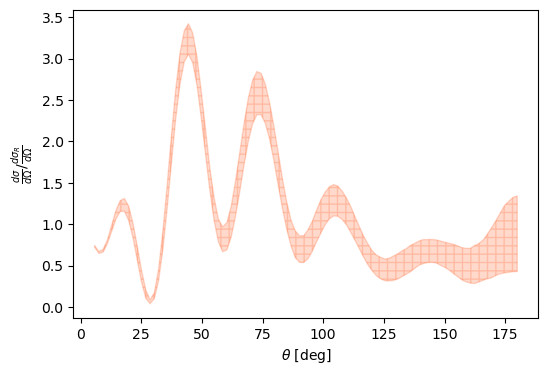

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.fill_between(
    angles * 180 / np.pi,
    kduq_pred_post[0], #/ solver.rutherford,
    kduq_pred_post[1], #/ solver.rutherford,
    color="#ff4500",
    hatch="|-|-",
    alpha=0.2,
)
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$\frac{d \sigma}{d\Omega} / \frac{d \sigma_{R}}{d\Omega} $")

In [9]:
#NBVAL_CHECK_OUTPUT
print(f"{kduq_pred_post[1][9]:1.6f}")

1.014334
